### imports

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import chess.svg
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import SVG, display

import utils.board as b

# Notebook 1: The Chess Environment

The KQK endgame environment used to train the agent. Covers the board representation, action space, reward function, and how they evolved across versions.

## 1. The KQK Endgame

**For anyone reading that is unfamiliar with chess:**

### Pieces
| Piece | How it moves |
|-------|--------------|
| King ♔ / ♚ | One square in any direction |
| Queen ♕ | Any number of squares in any direction |

### How games end
- **Checkmate**: the king is under attack with no escape → white wins
- **Stalemate**: black has no legal moves but is *not* in check → draw, white failed
- **Draws**: threefold repetition, fifty-move rule (50 moves without a capture), or only two kings left

### Why KQK?
King + Queen vs lone King. White must corner and checkmate the black king.

Starting here because:
- Only 3 pieces, simple rules
- Checkmate is clear and frequent enough to get a learning signal
- It's not trivial, a random policy mostly produces draws
- Hopefully scales to harder endgames

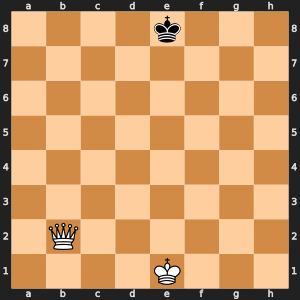

In [2]:
board = chess.Board("4k3/8/8/8/8/8/1Q6/4K3 w - - 0 1")
display(SVG(chess.svg.board(board, size=300)))

## 2. Board → Observation (768-dimensional vector)

The network needs a fixed-size numerical input. We encode the board as a flat binary vector of length 768:

```
obs[(piece_type - 1) * 128 + color * 64 + square] = 1.0
6 piece types × 2 colors × 64 squares = 768
```

In a KQK position, exactly 3 of the 768 values are 1.

### Why a flat vector and not a convolutional network?
The alternative is to represent the board as stacked 8×8 grids (one per piece type/color) and process them with a CNN, that's what AlphaZero (a big chess engine) does. Convolutions are good at picking up spatial patterns, but KQK only has 3 pieces and not much spatial structure to exploit. A flat vector fed into a plain MLP is simpler and works fine here.

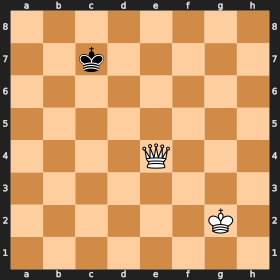

Non-zero positions in obs (total = 3):
  obs[ 540]  White  Queen   on e4
  obs[ 654]  White  King    on g2
  obs[ 754]  Black  King    on c7


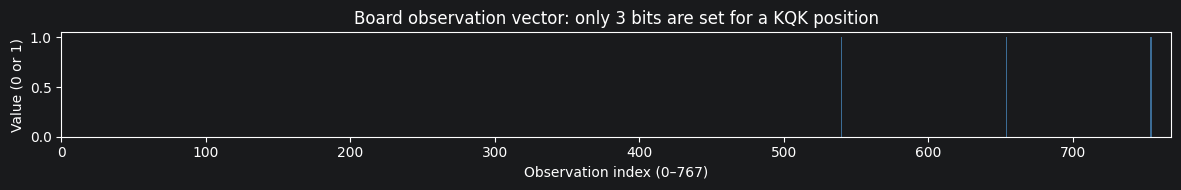

In [3]:
# Visualize: board → observation vector
board = b.random_kqk_position()
obs   = b.board_to_obs(board)

display(SVG(chess.svg.board(board, size=280)))

# Show which indices are non-zero
non_zero = np.where(obs > 0)[0]
piece_names = ["Pawn", "Knight", "Bishop", "Rook", "Queen", "King"]
colors      = ["White", "Black"]

print(f"Non-zero positions in obs (total = {len(non_zero)}):")
for idx in non_zero:
    pt_idx  = idx // 128
    color   = (idx % 128) // 64
    square  = idx % 64
    sq_name = chess.square_name(square)
    print(f"  obs[{idx:4d}]  {colors[color]:6s} {piece_names[pt_idx]:7s} on {sq_name}")

fig, ax = plt.subplots(figsize=(12, 2))
ax.bar(range(len(obs)), obs, width=1.0, color="steelblue", alpha=0.8)
ax.set_xlabel("Observation index (0–767)")
ax.set_ylabel("Value (0 or 1)")
ax.set_title("Board observation vector: only 3 bits are set for a KQK position")
ax.set_xlim(0, 768)
plt.tight_layout()
plt.show()

## 3. Action Space (4096 discrete actions)

Every square-to-square move gets a unique integer:
```
action = from_square * 64 + to_square  →  range [0, 4095]
```

Only about 10–30 of these 4096 actions are legal in any given position. Before sampling, illegal moves are zeroed out:
```python
mask = torch.full((4096,), float('-inf'))
mask[legal_actions] = 0.0
probs = softmax(logits + mask)
```

### Why fixed 4096 and not just list the legal moves?
The number of legal moves changes every step. A fixed output size means one network handles every position without needing a variable-size output.

In [4]:
# Show: legal actions for a sample position
board = chess.Board("4k3/8/8/8/8/8/1Q6/4K3 w - - 0 1")
legal_actions = [b.move_to_action(m) for m in board.legal_moves]
legal_moves   = [board.san(m) for m in board.legal_moves]

print(f"Board: {board.fen()}")
print(f"Legal move count: {len(legal_actions)}")
print()
for action, san in sorted(zip(legal_actions, legal_moves)):
    from_sq = action // 64
    to_sq   = action % 64
    print(f"  action={action:4d}  from={chess.square_name(from_sq)}  to={chess.square_name(to_sq)}  SAN={san}")

Board: 4k3/8/8/8/8/8/1Q6/4K3 w - - 0 1
Legal move count: 28

  action= 259  from=e1  to=d1  SAN=Kd1
  action= 261  from=e1  to=f1  SAN=Kf1
  action= 267  from=e1  to=d2  SAN=Kd2
  action= 268  from=e1  to=e2  SAN=Ke2
  action= 269  from=e1  to=f2  SAN=Kf2
  action= 576  from=b2  to=a1  SAN=Qa1
  action= 577  from=b2  to=b1  SAN=Qb1
  action= 578  from=b2  to=c1  SAN=Qc1
  action= 584  from=b2  to=a2  SAN=Qa2
  action= 586  from=b2  to=c2  SAN=Qc2
  action= 587  from=b2  to=d2  SAN=Qd2
  action= 588  from=b2  to=e2  SAN=Qe2+
  action= 589  from=b2  to=f2  SAN=Qf2
  action= 590  from=b2  to=g2  SAN=Qg2
  action= 591  from=b2  to=h2  SAN=Qh2
  action= 592  from=b2  to=a3  SAN=Qa3
  action= 593  from=b2  to=b3  SAN=Qb3
  action= 594  from=b2  to=c3  SAN=Qc3
  action= 601  from=b2  to=b4  SAN=Qb4
  action= 603  from=b2  to=d4  SAN=Qd4
  action= 609  from=b2  to=b5  SAN=Qb5+
  action= 612  from=b2  to=e5  SAN=Qe5+
  action= 617  from=b2  to=b6  SAN=Qb6
  action= 621  from=b2  to=f6  SAN=Qf6


## 4. Reward Function

| Version | Checkmate | Draw | Step penalty | Missed mate | Queen hang |
|---------|-----------|------|-------------|-------------|------------|
| env v1  | +1.0      | −1.0 | −0.001/step | —           | —          |
| env v2  | +10.0     | −1.0 | −0.001/step | —           | −0.5       |
| env v3  | +10.0     | −1.0 | −0.15/step  | −3.0        | −5.0       |
| env v4  | +10.0     | −1.0 | −0.15/step  | −3.0        | −5.0       |

### What each signal does

**Step penalty**: discourages stalling. Without it, the agent is happy to shuffle pieces for 200 steps.

**Missed-mate penalty** (−3.0): white had a checkmate available but didn't play it — end the episode with a penalty. Added after watching the agent skip mates it had seen hundreds of times.

**Queen-hang penalty** (−5.0): white moved the queen to a square the black king can immediately take — end the episode. Eliminated the agent's habit of sacrificing its only powerful piece.

**Checkmate scaling** (+1 → +10): bigger signal, easier to learn from early on.

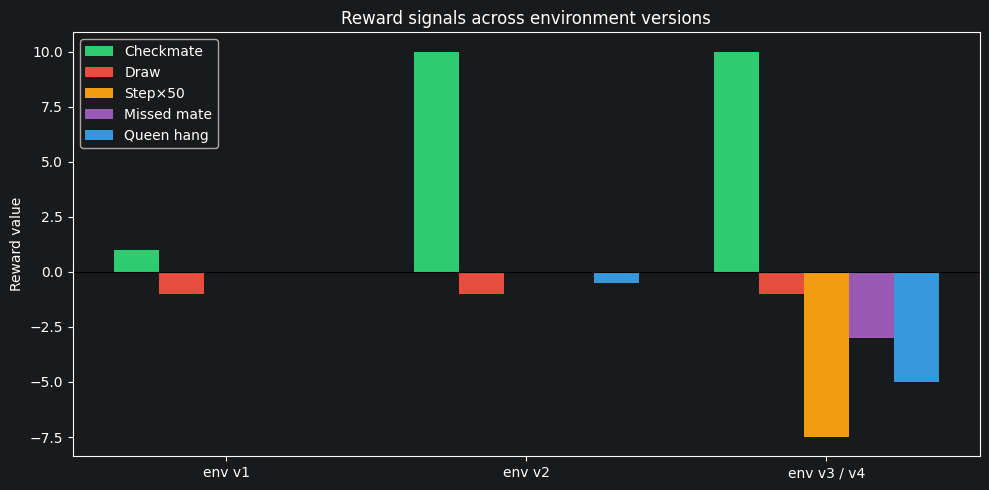

In [5]:
# Visualize: reward function comparison across versions
versions  = ["env v1", "env v2", "env v3 / v4"]
checkmate = [1.0,  10.0, 10.0]
draw      = [-1.0, -1.0, -1.0]
step_50   = [-0.001 * 50, -0.001 * 50, -0.15 * 50]  # total cost for a 50-step episode
missed    = [0,    0,    -3.0]
queen_h   = [0,    -0.5, -5.0]

x = np.arange(len(versions))
w = 0.15

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - 2*w, checkmate, w, label="Checkmate", color="#2ecc71")
b2 = ax.bar(x - 1*w, draw,      w, label="Draw",      color="#e74c3c")
b3 = ax.bar(x + 0*w, step_50,   w, label="Step×50",   color="#f39c12")
b4 = ax.bar(x + 1*w, missed,    w, label="Missed mate",color="#9b59b6")
b5 = ax.bar(x + 2*w, queen_h,   w, label="Queen hang", color="#3498db")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(versions)
ax.set_ylabel("Reward value")
ax.set_title("Reward signals across environment versions")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 5. Curriculum Learning

From a random KQK position, the agent might need 15–20 correct moves to reach checkmate. With random early actions, it almost never gets there — so there's nothing to learn from.

### Solution: mate-in-1 pool
We collected positions where white has an immediate checkmate available.
Each episode starts either from one of these (probability = `curriculum_ratio`) or from a random position.

```python
if random.random() < curriculum_ratio:
    board = chess.Board(random.choice(mate_pool))
else:
    board = random_kqk_position()
```

The agent sees checkmates constantly early on. Once it knows how to finish, we lower the ratio so it has to learn to get there from harder positions.

### Finding the right ratio
`1.0` (all mate-in-1): learns finishing fast, can't build a mating position from nothing.  
`0.3` worked best: a third curriculum, two thirds random.

## 6. Opponent Strategies

The environment controls the black king's moves.

| Env version | Opponent                                          |
|-------------|---------------------------------------------------|
| v1          | Random legal move                                 |
| v3          | Centrality heuristic or random (`movement_ratio`) |
| v4          | Any callable, used for neural network opponent    |

### Centrality movement (env v3)
The black king moves to whichever square is closest to the center:
```python
centrality(sq) = min(file(sq), 7 - file(sq), rank(sq), 7 - rank(sq))
```
A king in the center has more escape squares and is harder to checkmate than one stuck in a corner.

### Neural network opponent (env v4)
`opponent_fn(obs, legal_actions) → action` accepts any callable. We trained a `PPOOpponent` that plays as black and tries to survive as long as possible. Much harder than the heuristic — it actively avoids the edges.

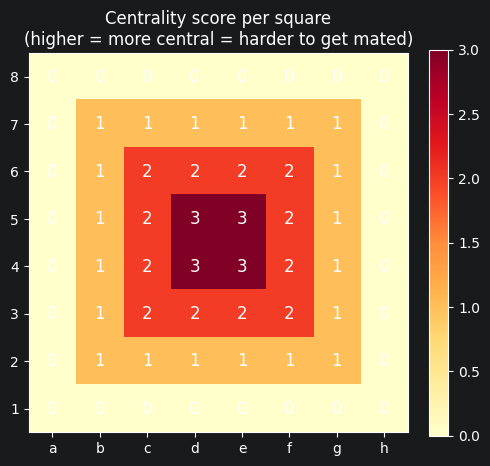

In [6]:
# Visualize: centrality values on an 8×8 board
centrality_grid = np.zeros((8, 8))
for sq in range(64):
    f = chess.square_file(sq)
    r = chess.square_rank(sq)
    centrality_grid[7 - r][f] = min(f, 7 - f, r, 7 - r)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(centrality_grid, cmap="YlOrRd", vmin=0, vmax=3)
for r in range(8):
    for f in range(8):
        ax.text(f, r, int(centrality_grid[r, f]), ha="center", va="center", fontsize=12)

ax.set_xticks(range(8)); ax.set_xticklabels(list("abcdefgh"))
ax.set_yticks(range(8)); ax.set_yticklabels(reversed(range(1, 9)))
ax.set_title("Centrality score per square\n(higher = more central = harder to get mated)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 7. Episode Termination Conditions

| Condition | Reward | Notes                                                           |
|-----------|--------|-----------------------------------------------------------------|
| **Checkmate** | +10.0 | White wins                                                      |
| **Stalemate** | −1.0  | Black has no legal move but is not in check: draw, white failed |
| **Insufficient material** | −1.0  | Happens if the queen gets captured                              |
| **Threefold repetition** | −1.0  | Same position 3 times                                           |
| **Fifty-move rule** | −1.0  | 50 moves without progress                                       |
| **Missed mate** | −3.0  | White had a checkmate available and didn't play it              |
| **Queen hang** | −5.0  | White left the queen where the black king can take it           |
| **Timeout** | 0.0   | 200 steps reached                                               |

Missed mate and queen hang are not standard chess rules, they were added to penalise obvious mistakes immediately rather than waiting for the effect to show up many moves later.